# Explore MixIT sound source separation

In [1]:
from opensoundscape import Audio, Spectrogram
from opensoundscape.audio import mix

import bioacoustics_model_zoo as bmz

import pandas as pd
import numpy as np

import matplotlib
from matplotlib import pyplot as plt
import IPython.display as ipd


import noisereduce as nr
import os,copy

# path = "/Users/lviotti/Library/CloudStorage/Dropbox/Work/Kitzes/datasets/omao-individual-recordings/"
# path_audio = os.path.join(path, "audio-clean/")
# out =  os.path.join(path, "audio-separated")
path = '/Users/lviotti/Library/CloudStorage/Dropbox/Work/Kitzes/projects/omao/'
path_data = os.path.join(path, 'training')
out = os.path.join(path, 'tmp')


# Little hack to get plotting spectrograms to work
os.environ['MPLBACKEND'] = 'TkAgg'

# os.getcwd()
os.chdir('/Users/lviotti/GitHub/omao/')

In [2]:
# Load annotation data

df = pd.read_csv(os.path.join(path_data, 'bcval-clips2s-centered_annotations.csv'))

# Keep only positive samples
df = df[df['annotation'] == '1']



In [3]:
# Load MiXIT model

model4 = bmz.SeparationModel(
  checkpoint='notebooks/bird_mixit_model_checkpoints/output_sources4/model.ckpt-3223090',
)

model8 = bmz.SeparationModel(
  checkpoint='notebooks/bird_mixit_model_checkpoints/output_sources8/model.ckpt-2178900',
)


INFO:tensorflow:Importing meta graph: notebooks/bird_mixit_model_checkpoints/output_sources4/inference.meta
Restoring model from checkpoint:  notebooks/bird_mixit_model_checkpoints/output_sources4/model.ckpt-3223090
INFO:tensorflow:Restoring parameters from notebooks/bird_mixit_model_checkpoints/output_sources4/model.ckpt-3223090


I0000 00:00:1761745395.110008 3318531 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled


INFO:tensorflow:Importing meta graph: notebooks/bird_mixit_model_checkpoints/output_sources8/inference.meta
Restoring model from checkpoint:  notebooks/bird_mixit_model_checkpoints/output_sources8/model.ckpt-2178900
INFO:tensorflow:Restoring parameters from notebooks/bird_mixit_model_checkpoints/output_sources8/model.ckpt-2178900


## Plotting functions

In [ ]:

def plot_original(df=None, idx=None, noise_reduce=None):
    if isinstance(df, Audio):
        # If df is actually an Audio object, use it directly
        clip_audio = df
        print("Using provided audio")
    elif isinstance(df, pd.DataFrame):
        # If df is a DataFrame, use idx to get the clip
        if idx is not None:
            clip = df.iloc[idx]
        else:
            clip = df.sample(1).iloc[0]
            idx = clip.name
        print(idx)
        clip_audio = Audio.from_file(clip.file, sample_rate=22050).trim(clip.start_time, clip.end_time)
    else:
        # Fallback to global df
        df_global = globals()['df']
        if idx is not None:
            clip = df_global.iloc[idx]
        else:
            clip = df_global.sample(1).iloc[0]
            idx = clip.name
        print(idx)
        clip_audio = Audio.from_file(clip.file, sample_rate=22050).trim(clip.start_time, clip.end_time)
    
    if noise_reduce:
        clip_nr = nr.reduce_noise(y=clip_audio.samples, sr=clip_audio.sample_rate, prop_decrease=noise_reduce, n_jobs=1)
        clip_audio = Audio(samples=clip_nr, sample_rate=22050)
    
    clip_spec = Spectrogram.from_audio(clip_audio, window_samples=200)
    clip_spec.plot()
    plt.show()

def plot_sparated_nr(df=None, idx=None, noise_reduce=None, model=model4):
    if isinstance(df, list) and all(isinstance(item, Audio) for item in df):
        # If df is actually a list of Audio objects, use it directly
        clip_separated = df
        print("Using provided audio list")
    elif isinstance(df, Audio):
        # If df is a single Audio object, separate it
        clip_separated = model.separate_audio(df)
        print("Using provided audio and separating")
    elif isinstance(df, pd.DataFrame):
        # If df is a DataFrame, use idx to get the clip and separate
        if idx is not None:
            clip = df.iloc[idx]
        else:
            clip = df.sample(1).iloc[0]
            idx = clip.name
        print(idx)
        clip_audio = Audio.from_file(clip.file, sample_rate=22050).trim(clip.start_time, clip.end_time)
        clip_separated = model.separate_audio(clip_audio)
    else:
        # Fallback to global df
        df_global = globals()['df']
        if idx is not None:
            clip = df_global.iloc[idx]
        else:
            clip = df_global.sample(1).iloc[0]
            idx = clip.name
        print(idx)
        clip_audio = Audio.from_file(clip.file, sample_rate=22050).trim(clip.start_time, clip.end_time)
        clip_separated = model.separate_audio(clip_audio)
    
    # Get the number of separated sources dynamically
    n_sources = len(clip_separated)
    
    # Calculate optimal subplot layout
    n_cols = int(np.ceil(np.sqrt(n_sources)))
    n_rows = int(np.ceil(n_sources / n_cols))
    
    # Set up the plot with dynamic subplot arrangement
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
    
    # Handle case where we have only one subplot
    if n_sources == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for i in range(n_sources):
        clip_audio = clip_separated[i]
        if noise_reduce:
            clip_nr = nr.reduce_noise(y=clip_audio.samples, sr=clip_audio.sample_rate, prop_decrease=noise_reduce, n_jobs=1)
            clip_audio = Audio(samples=clip_nr, sample_rate=22050)
        
        spec = Spectrogram.from_audio(clip_audio, window_samples=200)
        y = spec.frequencies
        t = spec.times
        S = spec.spectrogram

        im = axes[i].pcolormesh(t, y, S, shading="auto", cmap="Greys", vmin=-100, vmax=-20)
        axes[i].set_title(f'Source {i}')
        axes[i].set_xlabel("Time (sec)")
        axes[i].set_ylabel("Frequency (Hz)")

    # Hide any unused subplots
    for i in range(n_sources, len(axes)):
        axes[i].set_visible(False)

    plt.tight_layout()
    plt.show()


## Original clip

195


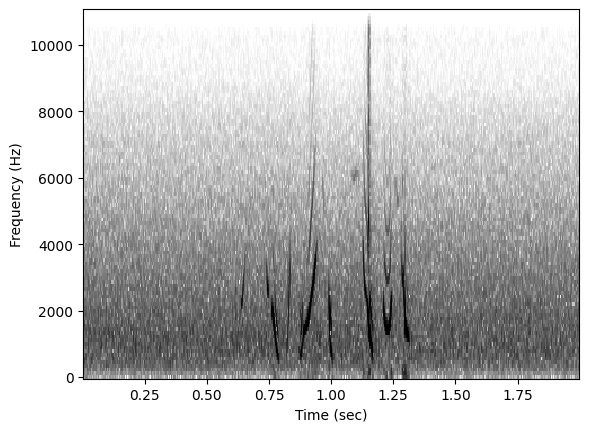

In [5]:
# plot_original(df, 42)
# plot_original(df, 504)
plot_original()

In [6]:
# plot_original(42, 0.99)
# plot_original(df, 504, 0.99)

## Separation

## Combination

Using provided audio


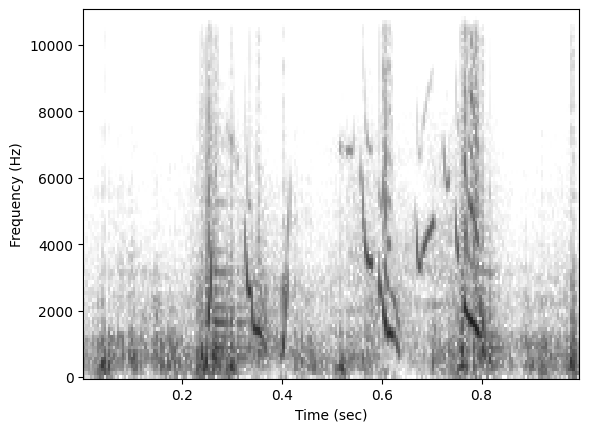

In [7]:
idx = 504
# idx = 113
# idx = 42
# idx = 1000


clip = df.iloc[idx]
clip_audio = Audio.from_file(clip.file,sample_rate=22050).trim(clip.start_time, clip.end_time)
clip_audio = clip_audio.trim(0.5, 1.5)


plot_original(clip_audio, noise_reduce = 0.9)



In [8]:
clip_audio

<Audio(samples=(22050,), sample_rate=22050)>

Using provided audio


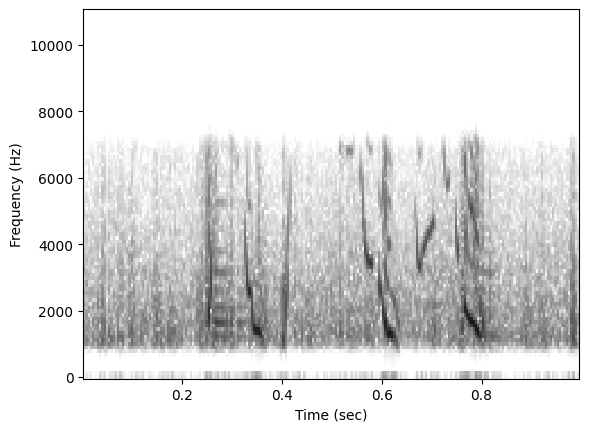

In [9]:
# Bandpass filter
clip_audio = clip_audio.bandpass(low_f=1000, high_f=7000, order=10)
plot_original(clip_audio)


Using provided audio list


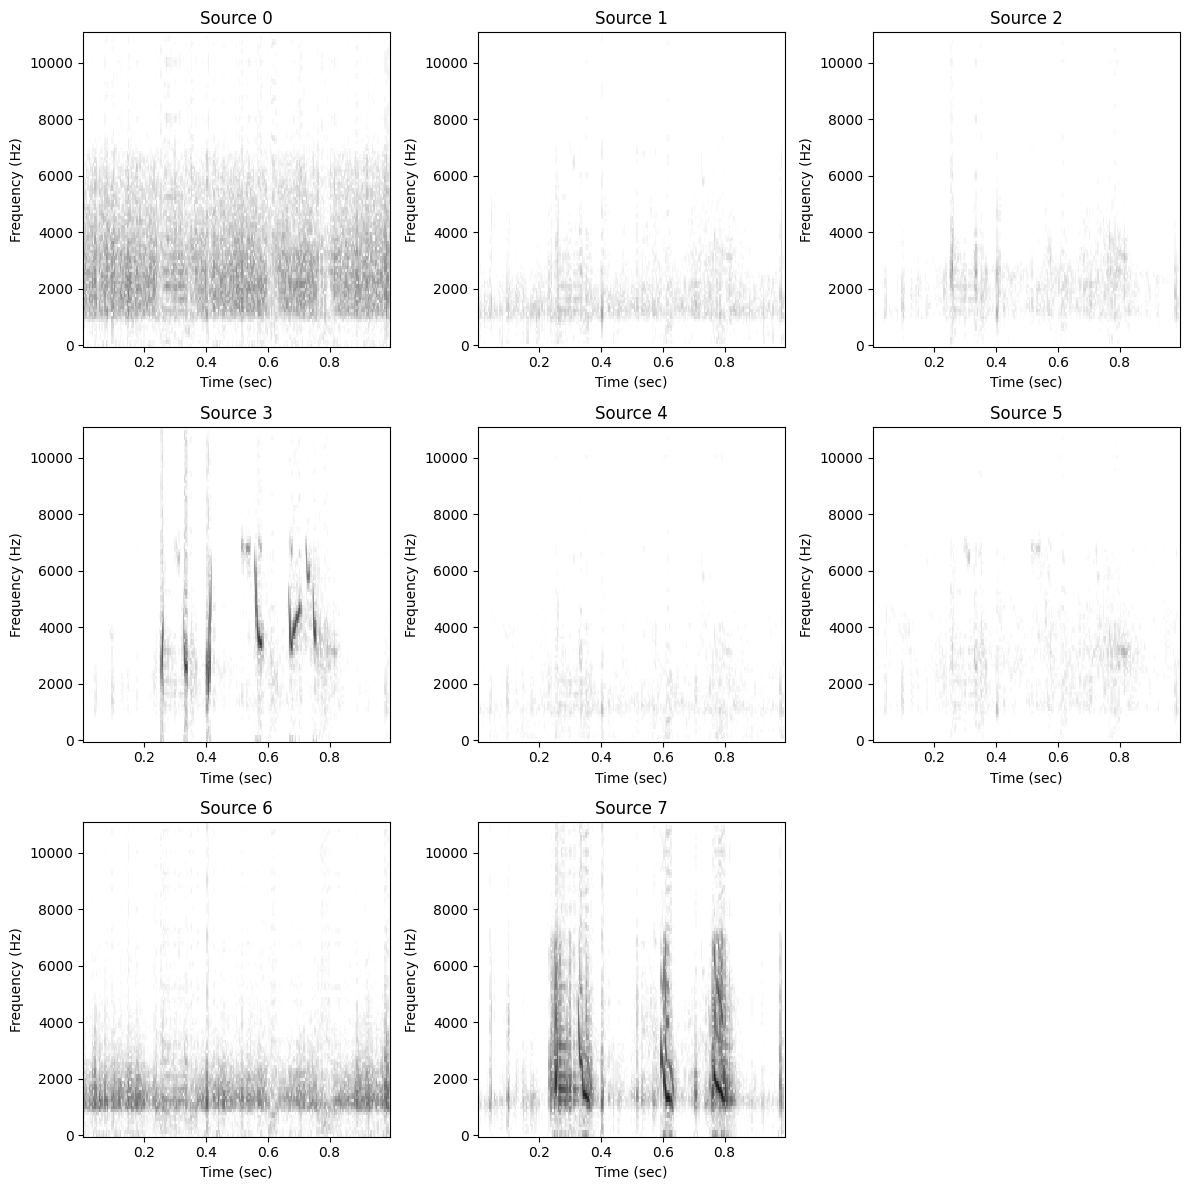

In [10]:
# Noise reduction
clip_audio_nr = nr.reduce_noise(y=clip_audio.samples, sr=clip_audio.sample_rate, prop_decrease=0.9, n_jobs=1)
clip_audio_nr = Audio(samples=clip_audio_nr, sample_rate=22050)


# clip_separated = model8.separate_audio(clip_audio_nr)
clip_separated = model8.separate_audio(clip_audio)


plot_sparated_nr(clip_separated, model = model8)

Using provided audio


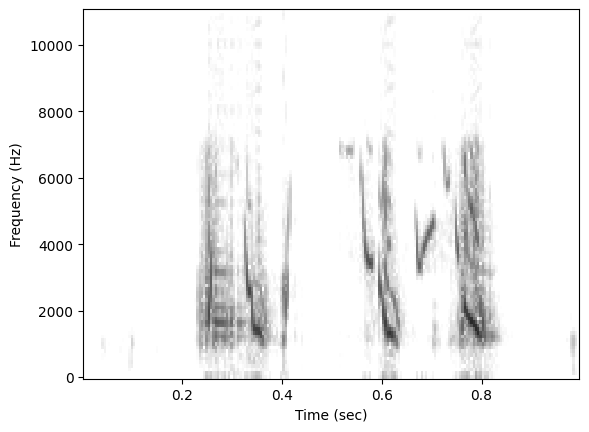

In [11]:
combined = mix([clip_separated[3], clip_separated[7]])
# combined = mix([clip_separated[5], clip_separated[7]])
# combined = mix([clip_separated[0], clip_separated[7]])
# combined = mix([clip_separated[3]])
# combined = mix([clip_separated[7]])


plot_original(combined, noise_reduce = 0.99)


# Draft - Can I clean these by pixel values?

In [19]:
combined
spec = Spectrogram.from_audio(combined, window_samples=200)
# foo = spec.to_image()
# type(spec)
spec_tensor = spec.to_image(return_type="torch")
spec_tensor.shape


torch.Size([1, 101, 219])

In [20]:
def show_tensor(tensor, title=None, cmap='gray_r'):
    """
    Display a 2D or 3D tensor as an image (e.g., spectrogram).
    Darker = higher values.
    """
    arr = tensor.detach().cpu().squeeze().numpy()

    plt.figure(figsize=(8, 4))
    plt.imshow(arr, origin='lower', aspect='auto', cmap=cmap)
    plt.colorbar(label='Value')
    plt.gca().invert_yaxis()
    if title:
        plt.title(title)
    plt.tight_layout()
    plt.show()

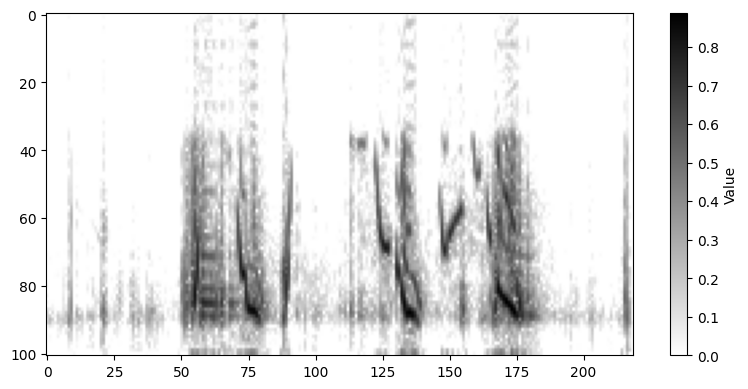

In [14]:
show_tensor(spec_tensor)

In [21]:
spec_tensor.mean(), spec_tensor.quantile(0.9)

(tensor(0.0939), tensor(0.3466))

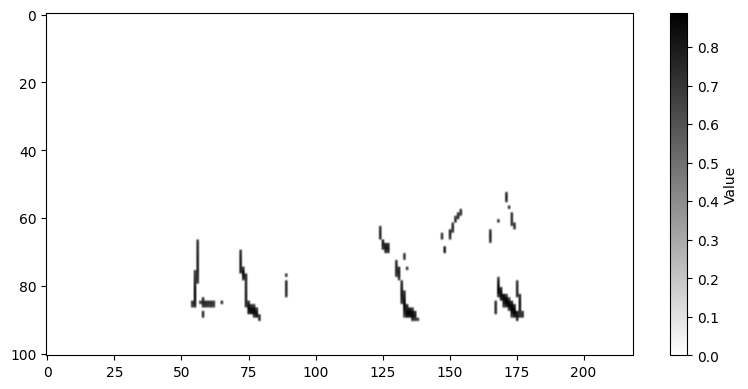

In [22]:
foo = copy.deepcopy(spec_tensor)
foo[foo < spec_tensor.quantile(0.99)] = 0
# foo[foo < foo.mean()] = 0

show_tensor(foo)


Try thresholding pixel values without separation

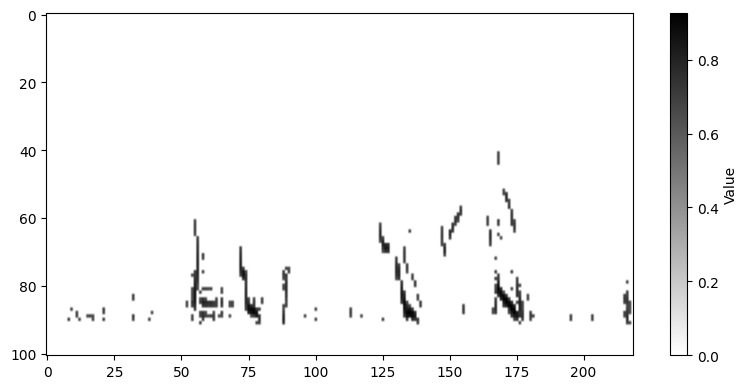

In [29]:
def pixel_value_thresholding(tensor, quantile=0.99):
    """
    Set pixel values below a quantile threshold to zero.
    
    Args:
        spectrogram: Spectrogram object to modify
        quantile: quantile threshold (between 0 and 1)
    
    Returns:
        A new Spectrogram object with pixel values below the threshold set to zero.
    """
    threshold = tensor.quantile(quantile)
    tensor[tensor < threshold] = 0
    
    return tensor


clip_audio

spec = Spectrogram.from_audio(clip_audio, window_samples=200)
spec_tensor = spec.to_image(return_type="torch")

# foo = copy.deepcopy(spec_tensor)
# foo[foo < spec_tensor.quantile(0.99)] = 0
# # foo[foo < foo.mean()] = 0
bar = pixel_value_thresholding(spec_tensor, quantile=0.98)
show_tensor(bar)
